# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**

Chanin Nantasenamat

[*'Data Professor' YouTube channel*](http://youtube.com/dataprofessor)

In this Jupyter notebook, we will be building a real-life **data science project** that you can include in your **data science portfolio**. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In **Part 2**, we will be performing Descriptor Calculation and Exploratory Data Analysis.

---

In [1]:
!pip install rdkit

## **Install conda and rdkit**

## **Load bioactivity data**

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv('bioactivity_preprocessed_data.csv')

## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

In [15]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 47.7 MB/s eta 0:00:00


### **Import libraries**

In [16]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [17]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [18]:
df_lipinski = lipinski(df.canonical_smiles)

### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [19]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,867.819,-4.19150,13.0,13.0
1,801.804,-3.74670,11.0,12.0
2,520.531,0.51700,3.0,11.0
3,313.404,5.28914,1.0,3.0
4,219.328,3.61800,1.0,2.0
5,414.687,1.88450,2.0,5.0
6,414.687,1.88450,2.0,5.0


In [20]:
df

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL3617787,CC(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CCC(=O)O)C(...,5390.00
1,CHEMBL3928693,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[C...,115.00
2,CHEMBL459546,COC(=O)[C@@]12OC[C@]34[C@H]([C@@H](O)[C@@H]1O)...,29.19
3,CHEMBL5288795,Cc1cc(C)cc(Nc2nc(C)c(-c3ccccc3)cc2C#N)c1,5000.00
4,CHEMBL5619019,Nc1ccc(OCCC2CCCCC2)cc1,2900.00
5,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,22.30
6,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,37.20


Now, let's combine the 2 DataFrame

In [21]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [22]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3617787,CC(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CCC(=O)O)C(...,5390.00,867.819,-4.19150,13.0,13.0
1,CHEMBL3928693,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[C...,115.00,801.804,-3.74670,11.0,12.0
2,CHEMBL459546,COC(=O)[C@@]12OC[C@]34[C@H]([C@@H](O)[C@@H]1O)...,29.19,520.531,0.51700,3.0,11.0
3,CHEMBL5288795,Cc1cc(C)cc(Nc2nc(C)c(-c3ccccc3)cc2C#N)c1,5000.00,313.404,5.28914,1.0,3.0
4,CHEMBL5619019,Nc1ccc(OCCC2CCCCC2)cc1,2900.00,219.328,3.61800,1.0,2.0
5,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,22.30,414.687,1.88450,2.0,5.0
6,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,37.20,414.687,1.88450,2.0,5.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [38]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [24]:
df_combined.standard_value.describe()

,standard_value
count,7.000000
mean,1927.670000
std,2465.315287
min,22.300000
25%,33.195000
50%,115.000000
75%,3950.000000
max,5390.000000


In [33]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [34]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [35]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [32]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL3617787,CC(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CCC(=O)O)C(...,867.819,-4.19150,13.0,13.0,5390.00
1,CHEMBL3928693,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[C...,801.804,-3.74670,11.0,12.0,115.00
2,CHEMBL459546,COC(=O)[C@@]12OC[C@]34[C@H]([C@@H](O)[C@@H]1O)...,520.531,0.51700,3.0,11.0,29.19
3,CHEMBL5288795,Cc1cc(C)cc(Nc2nc(C)c(-c3ccccc3)cc2C#N)c1,313.404,5.28914,1.0,3.0,5000.00
4,CHEMBL5619019,Nc1ccc(OCCC2CCCCC2)cc1,219.328,3.61800,1.0,2.0,2900.00
5,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,414.687,1.88450,2.0,5.0,22.30
6,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,414.687,1.88450,2.0,5.0,37.20


In [36]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,7.000000
mean,1927.670000
std,2465.315287
min,22.300000
25%,33.195000
50%,115.000000
75%,3950.000000
max,5390.000000


In [39]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL3617787,CC(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CCC(=O)O)C(...,867.819,-4.19150,13.0,13.0,5.268411
1,CHEMBL3928693,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[C...,801.804,-3.74670,11.0,12.0,6.939302
2,CHEMBL459546,COC(=O)[C@@]12OC[C@]34[C@H]([C@@H](O)[C@@H]1O)...,520.531,0.51700,3.0,11.0,7.534766
3,CHEMBL5288795,Cc1cc(C)cc(Nc2nc(C)c(-c3ccccc3)cc2C#N)c1,313.404,5.28914,1.0,3.0,5.301030
4,CHEMBL5619019,Nc1ccc(OCCC2CCCCC2)cc1,219.328,3.61800,1.0,2.0,5.537602
5,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,414.687,1.88450,2.0,5.0,7.651695
6,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,414.687,1.88450,2.0,5.0,7.429457


In [40]:
df_final.pIC50.describe()

,pIC50
count,7.000000
mean,6.523180
std,1.105351
min,5.268411
25%,5.419316
50%,6.939302
75%,7.482111
max,7.651695


### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [42]:
def classify_bioactivity(pIC50_value):
    if pIC50_value >= 6.0:
        return 'active'
    elif pIC50_value <= 5.0:
        return 'inactive'
    else:
        return 'intermediate'

df_final['bioactivity_class'] = df_final['pIC50'].apply(classify_bioactivity)

df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
1,CHEMBL3928693,CC(=O)N[C@@H](CC(=O)O)C(=O)N1CCC[C@H]1C(=O)N[C...,801.804,-3.7467,11.0,12.0,6.939302,active
2,CHEMBL459546,COC(=O)[C@@]12OC[C@]34[C@H]([C@@H](O)[C@@H]1O)...,520.531,0.5170,3.0,11.0,7.534766,active
5,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,414.687,1.8845,2.0,5.0,7.651695,active
6,CHEMBL1197091,O=C(CC1NCCCC1O)Cn1cnc2cc(Br)c(Cl)cc2c1=O,414.687,1.8845,2.0,5.0,7.429457,active


---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [43]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

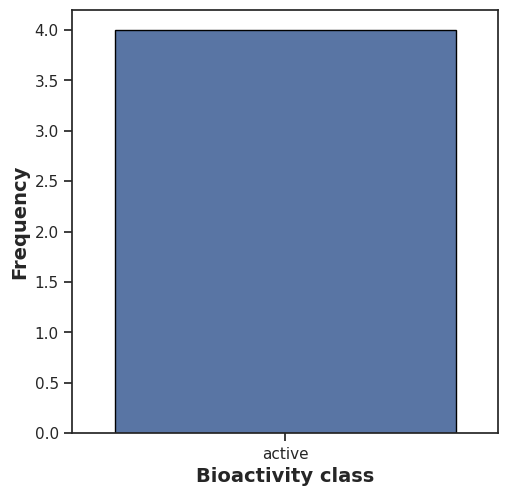

In [44]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

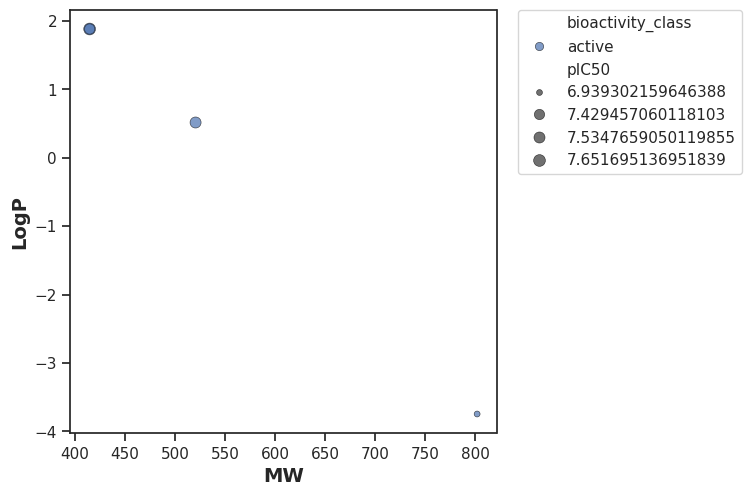

In [45]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

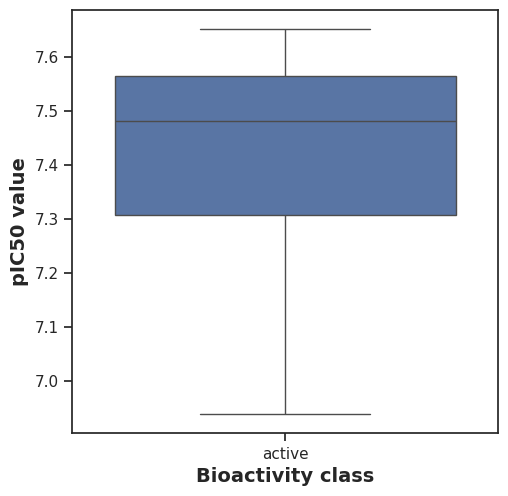

In [46]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [47]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [48]:
mannwhitney('pIC50')

/tmp/ipykernel_2104/568014129.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,NaN,NaN,0.05,Different distribution (reject H0)


#### **MW**

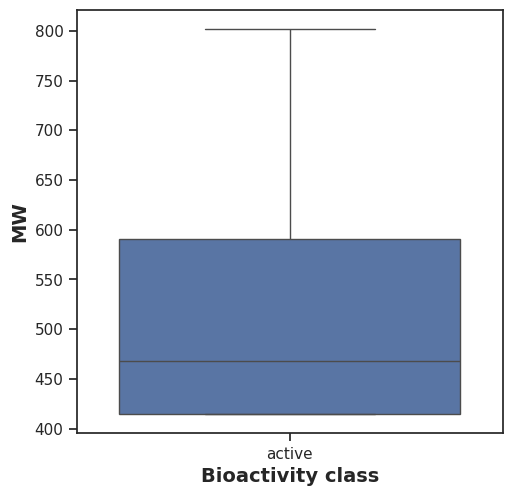

In [49]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [50]:
mannwhitney('MW')

/tmp/ipykernel_2104/568014129.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,MW,NaN,NaN,0.05,Different distribution (reject H0)


#### **LogP**

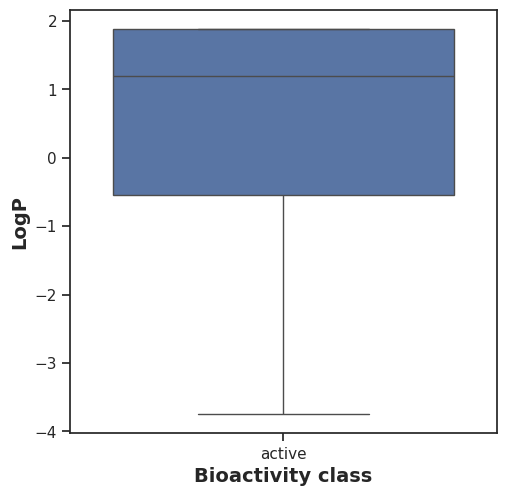

In [51]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [52]:
mannwhitney('LogP')

/tmp/ipykernel_2104/568014129.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,NaN,NaN,0.05,Different distribution (reject H0)


#### **NumHDonors**

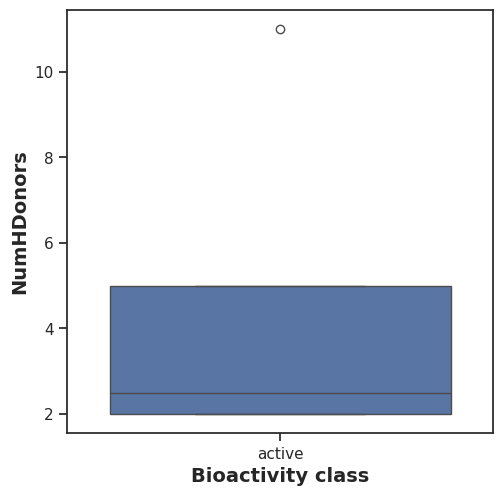

In [53]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [54]:
mannwhitney('NumHDonors')

/tmp/ipykernel_2104/568014129.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,NaN,NaN,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

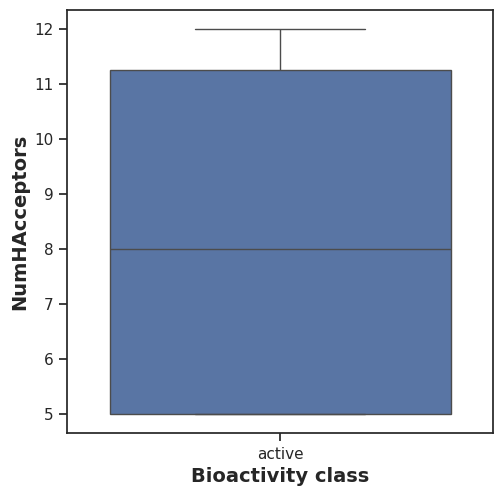

In [55]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [56]:
mannwhitney('NumHAcceptors')

/tmp/ipykernel_2104/568014129.py:22: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(active, inactive)


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,NaN,NaN,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited ***no difference*** between the **actives** and **inactives** while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.

## **Zip files**

In [57]:
! zip -r results.zip . -i *.csv *.pdf

  adding: bioactivity_preprocessed_data.csv (deflated 60%)
  adding: mannwhitneyu_MW.csv (deflated 6%)
  adding: mannwhitneyu_LogP.csv (deflated 6%)
  adding: plot_LogP.pdf (deflated 39%)
  adding: mannwhitneyu_pIC50.csv (deflated 9%)
  adding: plot_ic50.pdf (deflated 38%)
  adding: plot_MW_vs_LogP.pdf (deflated 33%)
  adding: plot_NumHAcceptors.pdf (deflated 37%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 9%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: plot_NumHDonors.pdf (deflated 37%)
  adding: plot_MW.pdf (deflated 39%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
